**02452** *Machine Learning intelligent systems classs*, Technical University of Denmark



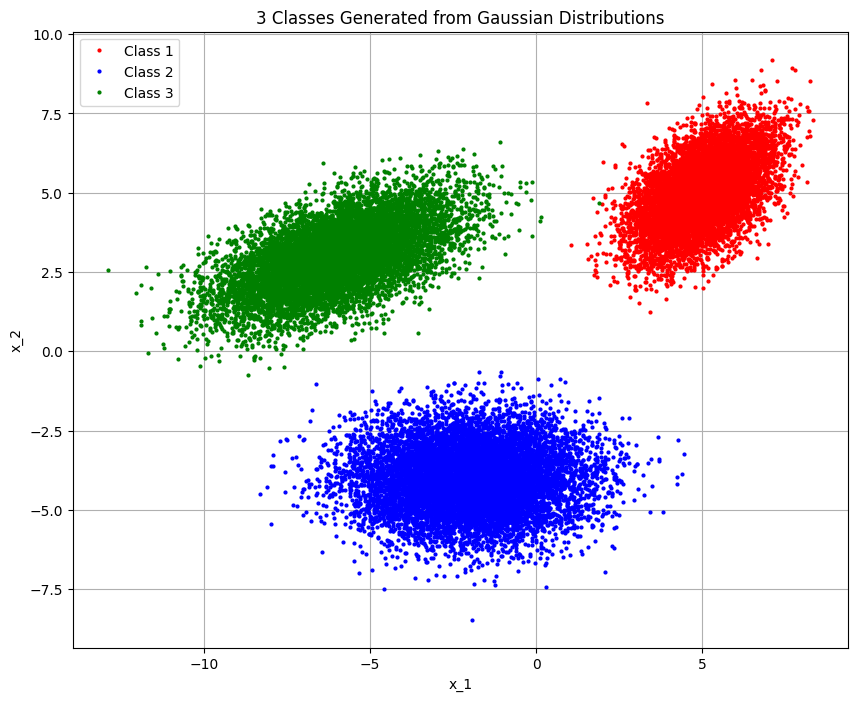

Dataset shape: (20000, 4)
Number of samples: 20000
Features shape: (20000, 2)
Labels shape: (20000, 2)
Single labels shape: (20000,)
Class distribution: Class 0: 10000, Class 1: 10000


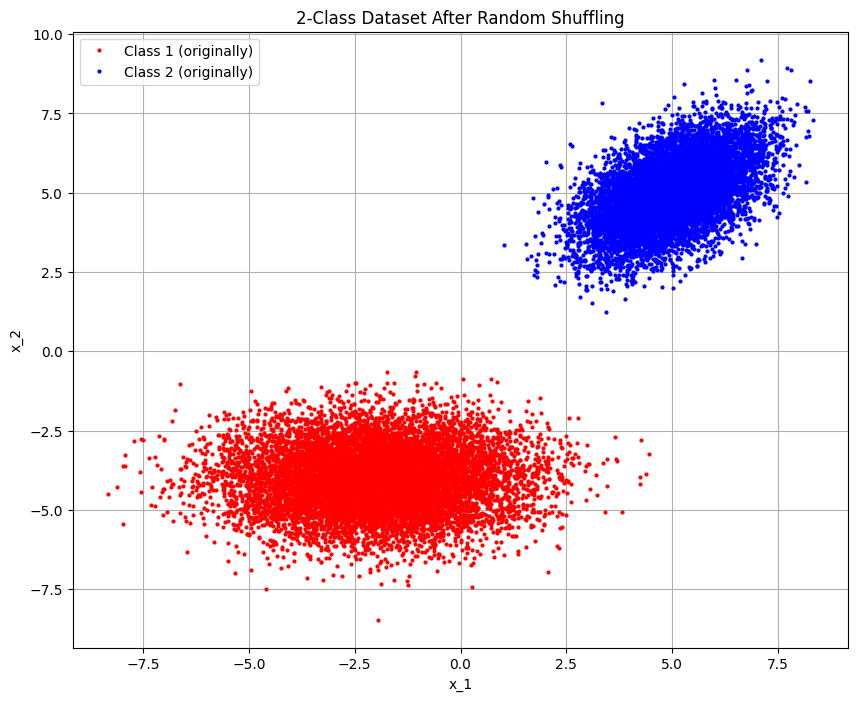


First 5 samples of the dataset:
Features (x1, x2) | One-hot labels | Single label
--------------------------------------------------
( -0.19,  -3.07) | [1.0, 0.0] | 0
( -2.48,  -2.28) | [1.0, 0.0] | 0
(  0.95,  -3.08) | [1.0, 0.0] | 0
( -4.78,  -3.97) | [1.0, 0.0] | 0
( -2.38,  -2.38) | [1.0, 0.0] | 0

DataFrame info:
         x1        x2  class
0 -0.191747 -3.071209      0
1 -2.481505 -2.276115      0
2  0.954390 -3.076903      0
3 -4.783234 -3.966001      0
4 -2.376025 -2.377642      0

Class distribution:
class
0    10000
1    10000
Name: count, dtype: int64


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import multivariate_normal, permutation

# Clear equivalent (not needed in Python, but for completeness)
plt.close('all')  # equivalent to 'close all'

# In the following we sample from Gaussian distribution to generate 3 clusters
L = int(10e3)  # 10,000 samples

# Class 1 parameters
mu_1 = np.array([5, 5])  # mean
Sigma_1 = np.array([[1, 0.5], [0.5, 1]])  # covariance
X_1 = multivariate_normal(mu_1, Sigma_1, L)  # drawing samples from 2D Gaussian distribution

# Class 2 parameters
mu_2 = np.array([-2, -4])
Sigma_2 = np.array([[3, 0], [0, 1]])
X_2 = multivariate_normal(mu_2, Sigma_2, L)

# Class 3 parameters
mu_3 = np.array([-6, 3])
Sigma_3 = np.array([[3, 1], [1, 1]])
X_3 = multivariate_normal(mu_3, Sigma_3, L)

# Plotting the three classes
plt.figure(figsize=(10, 8))
plt.plot(X_1[:, 0], X_1[:, 1], 'r.', markersize=4, label='Class 1')
plt.plot(X_2[:, 0], X_2[:, 1], 'b.', markersize=4, label='Class 2')
plt.plot(X_3[:, 0], X_3[:, 1], 'g.', markersize=4, label='Class 3')
plt.grid(True)
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.legend(['Class 1', 'Class 2', 'Class 3'])
plt.title('3 Classes Generated from Gaussian Distributions')
plt.show()

## Classification (2 classes)
# Generate labels for Class 1 (one-hot encoding: [0,1])
C_1 = np.tile([0, 1], (L, 1))  # equivalent to repmat([0,1],[L,1])

# Generate labels for Class 2 (one-hot encoding: [1,0])
C_2 = np.tile([1, 0], (L, 1))  # equivalent to repmat([1,0],[L,1])

# Data set containing two classes
# Form the data set. Samples X_1 and X_2 belong to Class 1 and 2, respectively.
data_set = np.hstack([
    np.vstack([X_1, X_2]),  # Stack X_1 and X_2 vertically
    np.vstack([C_1, C_2])   # Stack C_1 and C_2 vertically
])

# Random shuffling of the data set
rand_int = permutation(len(data_set))  # equivalent to randperm
data_set = data_set[rand_int, :]  # random shuffling

# Extract features and labels after shuffling
X_features = data_set[:, :2]  # First 2 columns are features
y_labels = data_set[:, 2:]    # Last 2 columns are one-hot encoded labels

# Convert one-hot labels to single label format (optional)
y_single = np.argmax(y_labels, axis=1)  # Convert [0,1] -> 0, [1,0] -> 1

# Display information about the dataset
print(f"Dataset shape: {data_set.shape}")
print(f"Number of samples: {len(data_set)}")
print(f"Features shape: {X_features.shape}")
print(f"Labels shape: {y_labels.shape}")
print(f"Single labels shape: {y_single.shape}")
print(f"Class distribution: Class 0: {np.sum(y_single == 0)}, Class 1: {np.sum(y_single == 1)}")

# Visualize the 2-class dataset after shuffling
plt.figure(figsize=(10, 8))
class_0_mask = y_single == 0
class_1_mask = y_single == 1

plt.plot(X_features[class_0_mask, 0], X_features[class_0_mask, 1], 
         'r.', markersize=4, label='Class 1 (originally)')
plt.plot(X_features[class_1_mask, 0], X_features[class_1_mask, 1], 
         'b.', markersize=4, label='Class 2 (originally)')
plt.grid(True)
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.legend()
plt.title('2-Class Dataset After Random Shuffling')
plt.show()

# Optional: Display first few samples to verify the structure
print("\nFirst 5 samples of the dataset:")
print("Features (x1, x2) | One-hot labels | Single label")
print("-" * 50)
for i in range(5):
    print(f"({X_features[i, 0]:6.2f}, {X_features[i, 1]:6.2f}) | "
          f"[{y_labels[i, 0]}, {y_labels[i, 1]}] | {y_single[i]}")

# Alternative approach: Using pandas for better data handling (optional)
try:
    import pandas as pd
    
    # Create a DataFrame for easier data manipulation
    df = pd.DataFrame({
        'x1': X_features[:, 0],
        'x2': X_features[:, 1],
        'class': y_single
    })
    
    print(f"\nDataFrame info:")
    print(df.head())
    print(f"\nClass distribution:")
    print(df['class'].value_counts().sort_index())
    
except ImportError:
    print("\nPandas not available, skipping DataFrame creation")

# Save the data if needed (equivalent to MATLAB's save function)
# np.savez('gaussian_data.npz', 
#          X_1=X_1, X_2=X_2, X_3=X_3, 
#          data_set=data_set, 
#          X_features=X_features, 
#          y_labels=y_labels, 
#          y_single=y_single)

In [5]:
# Python

import numpy as np


def train_test_split(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    split = int(len(X) * (1 - test_size))
    train_idx, test_idx = indices[:split], indices[split:]
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    return X_train, X_test, y_train, y_test

# Test 1: Check split sizes
X_train, X_test, y_train, y_test = train_test_split(X_features, y_single)
assert len(X_train) + len(X_test) == len(X_features), "Split sizes do not add up"
assert abs(len(X_test) - int(0.2 * len(X_features))) < 2, "Test size not ~20%"

# Test 2: Check no overlap
train_set = set(map(tuple, X_train))
test_set = set(map(tuple, X_test))
assert len(train_set.intersection(test_set)) == 0, "Train and test sets overlap"

# Test 3: Check class distribution preservation
def class_distribution(y):
    unique, counts = np.unique(y, return_counts=True)
    return dict(zip(unique, counts))

train_dist = class_distribution(y_train)
test_dist = class_distribution(y_test)
full_dist = class_distribution(y_single)

for cls in full_dist:
    train_ratio = train_dist.get(cls, 0) / len(y_train)
    test_ratio = test_dist.get(cls, 0) / len(y_test)
    full_ratio = full_dist[cls] / len(y_single)
    assert abs(train_ratio - full_ratio) < 0.05, f"Class {cls} train ratio off"
    assert abs(test_ratio - full_ratio) < 0.05, f"Class {cls} test ratio off"

print("All train/test split tests passed.")

All train/test split tests passed.


In [6]:
# Add bias column to features
X_bias = np.hstack([np.ones((X_features.shape[0], 1)), X_features])

# Use one-hot encoded labels for least squares
Y = y_labels

# Least squares solution for weight matrix
W = np.linalg.pinv(X_bias) @ Y

print("Weight matrix (least squares):")
print(W)

Weight matrix (least squares):
[[ 0.57960887  0.42039113]
 [-0.02453875  0.02453875]
 [-0.0872408   0.0872408 ]]


In [8]:
def least_squares_classifier(X_train, y_train):
    """
    Implement least squares method for binary classification
    
    The least squares solution is: W = (X^T X)^(-1) X^T Y
    where X is the design matrix with bias term and Y is the target matrix
    
    Args:
        X_train: Training features (N x 2)
        y_train: Training labels in one-hot format (N x 2)
    
    Returns:
        W: Weight matrix (3 x 2) including bias
    """
    
    # Add bias term (column of ones) to the feature matrix
    N = X_train.shape[0]
    X_design = np.column_stack([np.ones(N), X_train])  # N x 3 matrix
    
    print(f"Design matrix shape (with bias): {X_design.shape}")
    print(f"Target matrix shape: {y_train.shape}")
    
    # Compute the least squares solution: W = (X^T X)^(-1) X^T Y
    XtX = X_design.T @ X_design  # 3 x 3
    XtX_inv = np.linalg.inv(XtX)  # 3 x 3
    XtY = X_design.T @ y_train   # 3 x 2
    
    W = XtX_inv @ XtY  # 3 x 2
    
    print(f"Weight matrix shape: {W.shape}")
    
    return W, X_design


# Train the least squares classifier
W, X_train_design = least_squares_classifier(X_train, y_train)

print(f"\nLeast Squares Weight Matrix:")
print(f"W = \n{W}")
print(f"\nWeight matrix breakdown:")
print(f"Bias weights: {W[0, :]}")
print(f"x1 weights: {W[1, :]}")
print(f"x2 weights: {W[2, :]}")

Design matrix shape (with bias): (16000, 3)
Target matrix shape: (16000,)
Weight matrix shape: (3,)

Least Squares Weight Matrix:
W = 
[0.42046231 0.02474899 0.08720866]

Weight matrix breakdown:


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed